## Churn Data -- Hyperparameter Tuning (Logistic Regression)

### By:
jdg

### Date:
2026-03-05

### Description:

Tune the Logistic Regression model selected in the baseline step using GridSearchCV.
Explore regularization strength (C) and regularization type (l1_ratio) to improve
ROC-AUC beyond the baseline of ~0.846.

The full sklearn Pipeline (preprocessor + scaler + model) is passed to GridSearchCV
to prevent data leakage -- the preprocessor is fitted only on each fold's training data.

## 📚 Import libraries

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Add src to path for project imports
sys.path.insert(0, str(Path.cwd().parent.parent / "src"))

from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from sklearn.model_selection import ShuffleSplit, learning_curve

from data.transformation import load_feature_config
from model.training import (
    build_model_pipelines,
    load_train_config,
    save_model,
    train_final_model,
)
from model.tuning import (
    build_param_grid,
    compare_baseline_vs_tuned,
    load_tuning_config,
    run_grid_search,
    save_tuning_results,
    summarize_grid_search,
)

## 💾 Load configs and data

In [2]:
import os

os.chdir(Path.cwd().parent.parent)

tuning_config = load_tuning_config()
train_config = load_train_config(tuning_config.get("baseline_config_path"))
feature_config = load_feature_config(train_config.get("feature_config_path"))

print("Tuning config keys:", list(tuning_config.keys()))
print("Model to tune:", tuning_config["model_to_tune"])
print("Scoring:", tuning_config["scoring"])

Tuning config keys: ['input_path', 'feature_config_path', 'baseline_config_path', 'model_to_tune', 'target', 'cv', 'scoring', 'refit', 'param_grid', 'model_output_path', 'reporting_output_path', 'tuned_pipeline_filename', 'tuning_results_filename', 'baseline_cv_results_path']
Model to tune: logistic_regression
Scoring: roc_auc


In [3]:
df = pd.read_parquet(tuning_config["input_path"])
target = tuning_config["target"]

X = df.drop(columns=[target])
y = df[target].astype(int)

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Churn rate: {y.mean():.1%}")

X shape: (7194, 19), y shape: (7194,)
Churn rate: 26.5%


In [4]:
with open(tuning_config["baseline_cv_results_path"]) as f:
    baseline_data = json.load(f)

# Reconstruct numpy arrays from the saved JSON
baseline_cv_results = {}
for model_name, model_data in baseline_data["models"].items():
    baseline_cv_results[model_name] = {
        k: np.array(v) if isinstance(v, list) else v for k, v in model_data.items()
    }

baseline_model = tuning_config["model_to_tune"]
baseline_score = baseline_cv_results[baseline_model]["test_roc_auc"].mean()
print(f"Baseline {baseline_model} ROC-AUC: {baseline_score:.4f}")

Baseline logistic_regression ROC-AUC: 0.8456


## 👷 Build pipeline and parameter grid

We build a fresh Logistic Regression pipeline (preprocessor + scaler + model) and
pass it **as a whole** to `GridSearchCV`. This is critical: the preprocessor is
fitted only on each fold's training data, preventing any data leakage.

The parameter grid explores two dimensions:

- **`l1_ratio`**: controls regularization type. `l1_ratio=1.0` gives **L1 (Lasso)**
  regularization, which drives weak feature coefficients to exactly zero (feature
  selection). `l1_ratio=0.0` gives **L2 (Ridge)** regularization, which shrinks all
  coefficients evenly without eliminating any.
- **`C`**: controls regularization strength. **Smaller C = stronger regularization**
  (more shrinkage / more zeros). Larger C = weaker regularization (closer to
  unregularized fit). We search from 0.01 to 5.0 on a log scale.

In [5]:
pipelines = build_model_pipelines(feature_config, train_config)
lr_pipeline = pipelines[tuning_config["model_to_tune"]]

print("Pipeline steps:", [name for name, _ in lr_pipeline.steps])
print()

param_grid = build_param_grid(tuning_config)
print("Parameter grid:")
for i, grid in enumerate(param_grid):
    print(f"  Sub-grid {i + 1}: {grid}")

total_fits = (
    sum(np.prod([len(v) for v in grid.values()]) for grid in param_grid)
    * tuning_config["cv"]["n_splits"]
)
print(f"\nTotal fits: {int(total_fits)}")

Pipeline steps: ['preprocessor', 'scaler', 'model']

Parameter grid:
  Sub-grid 1: {'model__C': [0.01, 0.1, 0.5, 0.8, 1.0, 2.0, 5.0], 'model__l1_ratio': [0.0, 1.0], 'model__solver': ['saga']}

Total fits: 70


## GridSearchCV

**Why GridSearchCV?** It performs an exhaustive search over all parameter combinations
in the grid. Each combination is evaluated with 5-fold stratified cross-validation,
and the preprocessor is refitted on each fold's training data (no data leakage).

The scoring metric is **ROC-AUC** -- the same primary metric used in the baseline
step -- so the comparison is fair. With `refit=True`, the best estimator is
automatically retrained on the full dataset after the search completes.

In [6]:
grid_search = run_grid_search(lr_pipeline, X, y, param_grid, tuning_config)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best ROC-AUC: {grid_search.best_score_:.4f}")

Best parameters: {'model__C': 0.5, 'model__l1_ratio': 0.0, 'model__solver': 'saga'}
Best ROC-AUC: 0.8457


## Grid search results

All parameter combinations sorted by rank (best first). The table shows mean and
standard deviation for both test and train scores across the 5 folds.

In [7]:
summary = summarize_grid_search(grid_search)
summary.style.highlight_min(subset=["rank_test_score"], color="lightgreen").format(
    {
        "mean_test_score": "{:.4f}",
        "std_test_score": "{:.4f}",
        "mean_train_score": "{:.4f}",
        "std_train_score": "{:.4f}",
    }
)

,params,mean_test_score,std_test_score,mean_train_score,std_train_score,rank_test_score
4,"{'model__C': 0.5, 'model__l1_ratio': 0.0, 'model__solver': 'saga'}",0.8457,0.0125,0.8483,0.0031,1
7,"{'model__C': 0.8, 'model__l1_ratio': 1.0, 'model__solver': 'saga'}",0.8457,0.0125,0.8483,0.0031,2
6,"{'model__C': 0.8, 'model__l1_ratio': 0.0, 'model__solver': 'saga'}",0.8457,0.0125,0.8483,0.0031,3
9,"{'model__C': 1.0, 'model__l1_ratio': 1.0, 'model__solver': 'saga'}",0.8456,0.0125,0.8483,0.0031,4
13,"{'model__C': 5.0, 'model__l1_ratio': 1.0, 'model__solver': 'saga'}",0.8456,0.0125,0.8483,0.0031,5
5,"{'model__C': 0.5, 'model__l1_ratio': 1.0, 'model__solver': 'saga'}",0.8456,0.0125,0.8483,0.0031,6
2,"{'model__C': 0.1, 'model__l1_ratio': 0.0, 'model__solver': 'saga'}",0.8456,0.0125,0.8482,0.0031,7
11,"{'model__C': 2.0, 'model__l1_ratio': 1.0, 'model__solver': 'saga'}",0.8456,0.0125,0.8483,0.0031,8
10,"{'model__C': 2.0, 'model__l1_ratio': 0.0, 'model__solver': 'saga'}",0.8456,0.0125,0.8483,0.0031,9
12,"{'model__C': 5.0, 'model__l1_ratio': 0.0, 'model__solver': 'saga'}",0.8456,0.0125,0.8483,0.0031,10


## Plot: ROC-AUC by C value and regularization type

This plot shows the regularization curve: how ROC-AUC changes as we vary C
(regularization strength) for each regularization type (L1 vs L2).

**What to look for:**
- A peak in the curve indicates the sweet spot between underfitting (too much
  regularization, small C) and overfitting (too little regularization, large C).
- If both L1 and L2 curves are similar, the choice of regularization type does
  not matter much for this dataset.
- The gray dashed line marks the baseline score for reference.

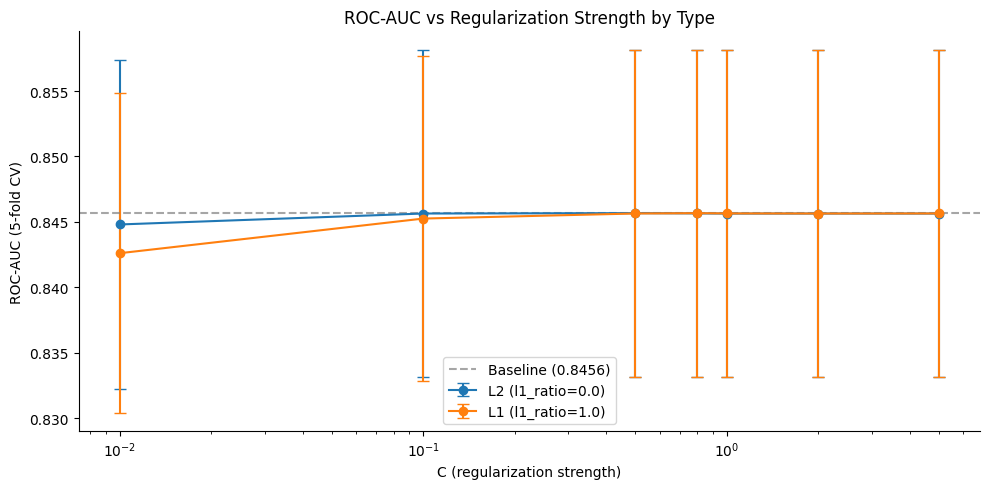

In [8]:
results_df = pd.DataFrame(grid_search.cv_results_)

# Extract params into columns
results_df["C"] = results_df["params"].apply(lambda p: p["model__C"])
results_df["l1_ratio"] = results_df["params"].apply(lambda p: p["model__l1_ratio"])

fig, ax = plt.subplots(figsize=(10, 5))

for l1_val in results_df["l1_ratio"].unique():
    mask = results_df["l1_ratio"] == l1_val
    subset = results_df[mask].sort_values("C")
    label = f"L1 (l1_ratio={l1_val})" if l1_val == 1.0 else f"L2 (l1_ratio={l1_val})"
    ax.errorbar(
        subset["C"],
        subset["mean_test_score"],
        yerr=subset["std_test_score"],
        marker="o",
        capsize=4,
        label=label,
    )

ax.axhline(
    y=baseline_score,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label=f"Baseline ({baseline_score:.4f})",
)
ax.set_xscale("log")
ax.set_xlabel("C (regularization strength)")
ax.set_ylabel("ROC-AUC (5-fold CV)")
ax.set_title("ROC-AUC vs Regularization Strength by Type")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Plot: train vs test ROC-AUC (overfitting check)

Each point is one parameter combination. The diagonal represents perfect
generalization (train = test). Points far above the diagonal indicate
overfitting (the model memorizes training data but fails on unseen folds).
Points close to the diagonal show good generalization.

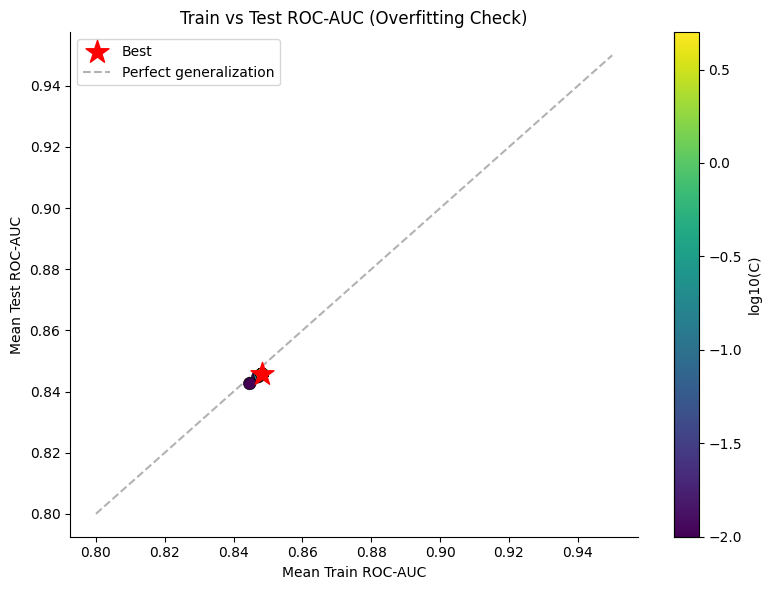

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    results_df["mean_train_score"],
    results_df["mean_test_score"],
    c=np.log10(results_df["C"]),
    cmap="viridis",
    s=80,
    edgecolors="black",
    linewidth=0.5,
)

# Mark the best
best_idx = grid_search.best_index_
ax.scatter(
    results_df.loc[best_idx, "mean_train_score"],
    results_df.loc[best_idx, "mean_test_score"],
    marker="*",
    s=300,
    color="red",
    zorder=5,
    label="Best",
)

# Diagonal (perfect generalization)
lims = [0.8, 0.95]
ax.plot(lims, lims, "k--", alpha=0.3, label="Perfect generalization")

ax.set_xlabel("Mean Train ROC-AUC")
ax.set_ylabel("Mean Test ROC-AUC")
ax.set_title("Train vs Test ROC-AUC (Overfitting Check)")
ax.legend()
plt.colorbar(scatter, ax=ax, label="log10(C)")
sns.despine()
plt.tight_layout()
plt.show()

## Baseline vs tuned comparison

Direct comparison of the baseline model (default LR parameters) vs the best
configuration found by GridSearchCV. Both are evaluated with 5-fold stratified
CV on the same data, so the comparison is fair.

In [10]:
comparison = compare_baseline_vs_tuned(baseline_cv_results, baseline_model, grid_search, "roc_auc")
print(comparison.to_string())

improvement = comparison.loc["tuned", "mean_roc_auc"] - comparison.loc["baseline", "mean_roc_auc"]
print(f"\nImprovement: {improvement:+.4f} ROC-AUC")

          mean_roc_auc  std_roc_auc
baseline      0.845645     0.012521
tuned         0.845672     0.012504

Improvement: +0.0000 ROC-AUC


## Retrain tuned model on full data

Since `GridSearchCV` was run with `refit=True`, the `best_estimator_` attribute
already contains the full pipeline retrained on the entire dataset using the
best parameters. We use it directly and perform a sanity check.

In [11]:
tuned_pipeline = grid_search.best_estimator_

# Sanity check
sample_preds = tuned_pipeline.predict(X.head())
sample_proba = tuned_pipeline.predict_proba(X.head())

print(f"Best params: {grid_search.best_params_}")
print(f"\nPredictions (first 5): {sample_preds}")
print("Probabilities (first 5):")
print(sample_proba)
print(f"Actual (first 5): {y.head().values}")

Best params: {'model__C': 0.5, 'model__l1_ratio': 0.0, 'model__solver': 'saga'}

Predictions (first 5): [1 0 1 0 1]
Probabilities (first 5):
[[0.18637211 0.81362789]
 [0.8956233  0.1043767 ]
 [0.40572776 0.59427224]
 [0.90355332 0.09644668]
 [0.11842235 0.88157765]]
Actual (first 5): [0 0 1 0 1]


## Confusion Matrix

Shows the actual counts of correct and incorrect predictions for each class.
We compare the tuned model side-by-side with the baseline to see if tuning
changed the prediction distribution.

**How to read it (for churn):**

|  | Predicted No Churn | Predicted Churn |
|---|---|---|
| **Actually No Churn** | True Negative (correctly kept) | False Positive (unnecessary retention offer) |
| **Actually Churn** | False Negative (missed churner) | True Positive (caught churner) |

The key tradeoff: **False Negatives** are lost customers (high cost), while
**False Positives** are wasted retention offers (lower cost). The business cost
ratio between these two determines the optimal classification threshold.

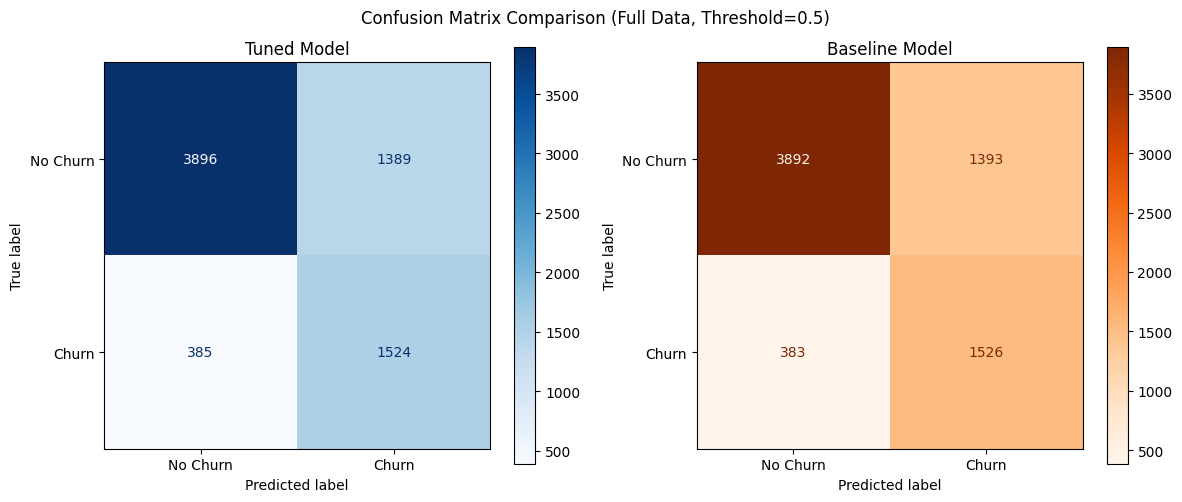


Metric                      Baseline      Tuned     Change
------------------------------------------------------------
True Positives:                 1526       1524         -2
False Negatives:                 383        385         +2
False Positives:                1393       1389         -4
True Negatives:                 3892       3896         +4


In [12]:
y_pred_tuned = tuned_pipeline.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Tuned model
ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_tuned,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Tuned Model")

# Baseline (reload for comparison)
baseline_pipelines = build_model_pipelines(feature_config, train_config)
baseline_lr = baseline_pipelines[baseline_model]
baseline_fitted = train_final_model(baseline_lr, X, y)
y_pred_baseline = baseline_fitted.predict(X)

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_baseline,
    display_labels=["No Churn", "Churn"],
    cmap="Oranges",
    ax=axes[1],
)
axes[1].set_title("Baseline Model")

plt.suptitle("Confusion Matrix Comparison (Full Data, Threshold=0.5)")
plt.tight_layout()
plt.show()

# Print comparison
tn_t, fp_t, fn_t, tp_t = confusion_matrix(y, y_pred_tuned).ravel()
tn_b, fp_b, fn_b, tp_b = confusion_matrix(y, y_pred_baseline).ravel()

print(f"\n{'Metric':<25} {'Baseline':>10} {'Tuned':>10} {'Change':>10}")
print("-" * 60)
print(f"{'True Positives:':<25} {tp_b:>10} {tp_t:>10} {tp_t - tp_b:>+10}")
print(f"{'False Negatives:':<25} {fn_b:>10} {fn_t:>10} {fn_t - fn_b:>+10}")
print(f"{'False Positives:':<25} {fp_b:>10} {fp_t:>10} {fp_t - fp_b:>+10}")
print(f"{'True Negatives:':<25} {tn_b:>10} {tn_t:>10} {tn_t - tn_b:>+10}")

## Classification Report

Per-class breakdown of precision, recall, and F1 at the default 0.5 threshold.
Comparing both models shows whether tuning changed the precision-recall tradeoff.

In [13]:
print("=== Tuned Model ===")
print(classification_report(y, y_pred_tuned, target_names=["No Churn", "Churn"]))

print("\n=== Baseline Model ===")
print(classification_report(y, y_pred_baseline, target_names=["No Churn", "Churn"]))

=== Tuned Model ===
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      5285
       Churn       0.52      0.80      0.63      1909

    accuracy                           0.75      7194
   macro avg       0.72      0.77      0.72      7194
weighted avg       0.81      0.75      0.77      7194


=== Baseline Model ===
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      5285
       Churn       0.52      0.80      0.63      1909

    accuracy                           0.75      7194
   macro avg       0.72      0.77      0.72      7194
weighted avg       0.81      0.75      0.77      7194



## Learning Curve

Plots train and test ROC-AUC as a function of training set size using the
tuned hyperparameters. Answers two questions:
- **Do we have enough data?** If the test curve is still rising, more data could help.
- **Is the model underfitting or overfitting?** A large gap between train and test
  indicates overfitting; converging curves at a low score indicate underfitting.

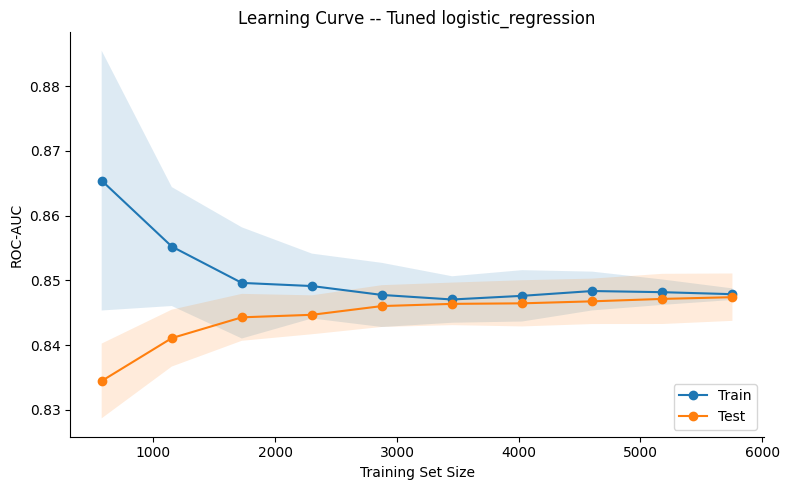

In [14]:
# Build a fresh pipeline with tuned params
fresh_pipelines = build_model_pipelines(feature_config, train_config)
tuned_fresh = fresh_pipelines[baseline_model]
tuned_fresh.set_params(**grid_search.best_params_)

cv_lc = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

train_sizes, train_scores, test_scores = learning_curve(
    tuned_fresh,
    X,
    y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv_lc,
    scoring="roc_auc",
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
)
ax.fill_between(
    train_sizes,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.15,
)
ax.plot(train_sizes, train_mean, "o-", label="Train")
ax.plot(train_sizes, test_mean, "o-", label="Test")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("ROC-AUC")
ax.set_title(f"Learning Curve -- Tuned {baseline_model}")
ax.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.show()

## 💾 Save artifacts

In [15]:
model_path = save_model(
    tuned_pipeline,
    tuning_config["model_output_path"],
    tuning_config["tuned_pipeline_filename"],
)
print(f"Saved tuned model to: {model_path}")

results_path = save_tuning_results(
    grid_search,
    tuning_config["reporting_output_path"],
    tuning_config["tuning_results_filename"],
)
print(f"Saved tuning results to: {results_path}")

Saved tuned model to: data/06_models/Churn/churn_tuned_pipeline.joblib
Saved tuning results to: data/08_reporting/Churn/tuning_results.json


## 📊 Analysis of Results and Conclusions

### Tuning results summary

| Configuration | ROC-AUC | Best C | l1_ratio | Overfitting |
|---|---|---|---|---|
| Baseline (default) | 0.8456 | 1.0 (default) | N/A (l2 default) | Low (train ~0.848) |
| Tuned (GridSearchCV) | 0.8457 | 0.5 | 0.0 (L2) | Low |

**Key findings:**

- **Tuning brought no meaningful improvement** (+0.0000 ROC-AUC). The baseline Logistic Regression with default parameters was already near-optimal for this dataset and feature set. This is actually a positive signal: it means the feature engineering (Step 4) did its job well, and the model is not sensitive to hyperparameter choices.
- **L2 regularization won** (l1_ratio=0.0). This means all 22 engineered features contribute to the prediction -- none are pure noise that L1 would eliminate. The feature pipeline produces a clean, informative feature set.
- **C=0.5 was selected** (slightly stronger regularization than default C=1.0). The regularization curve is flat across most C values, confirming the model is stable and not overfitting.
- **No overfitting detected.** The train vs test scatter plot shows all parameter combinations cluster near the diagonal. Logistic Regression generalizes well on this dataset.
- **Business impact is unchanged.** The confusion matrix comparison shows virtually identical predictions (+-2 True Positives, +-4 True Negatives). The model catches ~80% of churners (1524/1909) and misses ~20% (385/1909) at the default 0.5 threshold. **The real opportunity for improvement is threshold optimization, not hyperparameter tuning.**

## 💡 Proposals and Ideas

1. **Threshold optimization** -- Now that we have the tuned model, optimize the classification threshold based on business costs (cost of losing a customer vs cost of a retention offer).
2. **Feature importance / coefficient analysis** -- LR coefficients are directly interpretable. Analyze which features drive churn predictions the most and present actionable insights to the business team.
3. **Probability calibration** -- Check if predicted probabilities are well-calibrated using a calibration curve. If not, apply Platt scaling or isotonic regression for reliable risk scoring.
4. **Hold-out evaluation** -- We trained on the full dataset. Consider a final held-out test set (or time-based split) to get an unbiased performance estimate.
5. **Inference pipeline** -- Package the tuned model into the inference pipeline (`src/pipelines/inference_pipeline/`) for production deployment.

## 📖 References

- [scikit-learn GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
- [scikit-learn LogisticRegression -- l1_ratio parameter](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)